Fasion MNIST Classifier

In [4]:
#bibliotheken
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Input, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy

import numpy as np


print(tf.__version__)

2.20.0


1. Daten laden und verarbeiten

In [5]:
# Data importieren 
# Bilder 28x28 pxl NumPy Arrays, labels in range 0...9 
# Train Bilder: 60000, Test Bilder: 10000

fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels),(test_images, test_labels) = fashion_mnist.load_data()

print(train_labels[0])
print(train_images[0])

9
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 

In [6]:
#Klassen Namen Array initialisieren
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(list(enumerate(class_names)))

[(0, 'T-shirt/top'), (1, 'Trouser'), (2, 'Pullover'), (3, 'Dress'), (4, 'Coat'), (5, 'Sandal'), (6, 'Shirt'), (7, 'Sneaker'), (8, 'Bag'), (9, 'Ankle boot')]


In [7]:
#Data type und shape
print(type(train_images))
print(train_images.shape)
len(train_labels)

<class 'numpy.ndarray'>
(60000, 28, 28)


60000

In [8]:
# Data normalisieren (von 0...255 Pixelwerte nach 0...1 Werte)
train_images = train_images/255.0
test_images = test_images/255.0

np.set_printoptions(suppress=True)  # !!! damit wir kein 0.00000000e+00 in print bekommen
print(train_images[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.00392157 0.    

2. Modellarchitektur bauen

In [9]:
#Erstellung eines Sequential-Modell
#!!! Input Layer mis erste sein !!!
#mit Flatten: 28x28 pxl to 1D Vektor

model = Sequential([    
                    Input(shape=(28,28)),
                    Flatten(),
                    Dense(128,activation="relu"),
                    Dense(10,activation='softmax')
                    ])

# model = tf.keras.Sequential([
    
#     tf.keras.layers.Flatten(input_shape=(28,28)),
#     tf.keras.layers.Dense(128,activation="relu"),
#     tf.keras.layers.Dense(10, activation="softmax")
# ])

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

3. Kompilieren

In [11]:
# Modell kompilieren
model.compile(Adam(),                              #logits sind rohe Werte 
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics = ['accuracy']
)

4. Training und Evaluation

In [12]:
#training
model.fit(train_images, train_labels, epochs=10,batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8192 - loss: 0.5197 - val_accuracy: 0.8207 - val_loss: 0.4939
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8599 - loss: 0.3911 - val_accuracy: 0.8678 - val_loss: 0.3797
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8733 - loss: 0.3471 - val_accuracy: 0.8572 - val_loss: 0.3844
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8819 - loss: 0.3236 - val_accuracy: 0.8667 - val_loss: 0.3730
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8900 - loss: 0.3030 - val_accuracy: 0.8812 - val_loss: 0.3318
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8936 - loss: 0.2886 - val_accuracy: 0.8863 - val_loss: 0.3234
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8974 - loss: 0.2772 - val_accuracy: 0.8830 - val_loss: 0.3254
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9027 - loss: 0.2639 - 

In [13]:
#evaluation
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.8790 - loss: 0.3463
Test accuracy: 0.8790


5. Make predictions

In [14]:
# neues Modell
propability_model = Sequential([model, keras.layers.Softmax()])

In [15]:
#Vorhersage machen
pred = propability_model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [16]:
#erste Vorhersage
pred[0]
#array von 10 Wahrscheinlichkeiten der Labels 0...9

array([0.08548193, 0.0854817 , 0.0854817 , 0.0854817 , 0.0854817 ,
       0.08609264, 0.08548193, 0.08587271, 0.08548181, 0.22966224],
      dtype=float32)

In [17]:
#welches Label den höchste Konfidenzwert hat
np.argmax(pred[0])

np.int64(9)

In [18]:
#Entscheidung prüfen
test_labels[0]

np.uint8(9)

In [19]:
#Andere Vorhersage mit Realität verdleichen
n=11
pred[n]
print(f"Klassifizierung: {np.argmax(pred[n])}")
print(f"Original: {test_labels[n]}")

Klassifizierung: 5
Original: 5


In [20]:
#Array von vorhersagte Labels
pred_labels = np.argmax(pred, axis=-1)
print(pred_labels[:10])

[9 2 1 1 6 1 4 6 5 7]


6. Visualisierung.

6.1 Modell Visualisierung

In [21]:
###Schematische darstellung (Text-Diagramm)
# Input Layer: 28x28
#        |
# Flattern Layer: 784
#        |
# Dense Layer 128 (ReLU)
#        |
# Dense Layer 10 (Softmax)

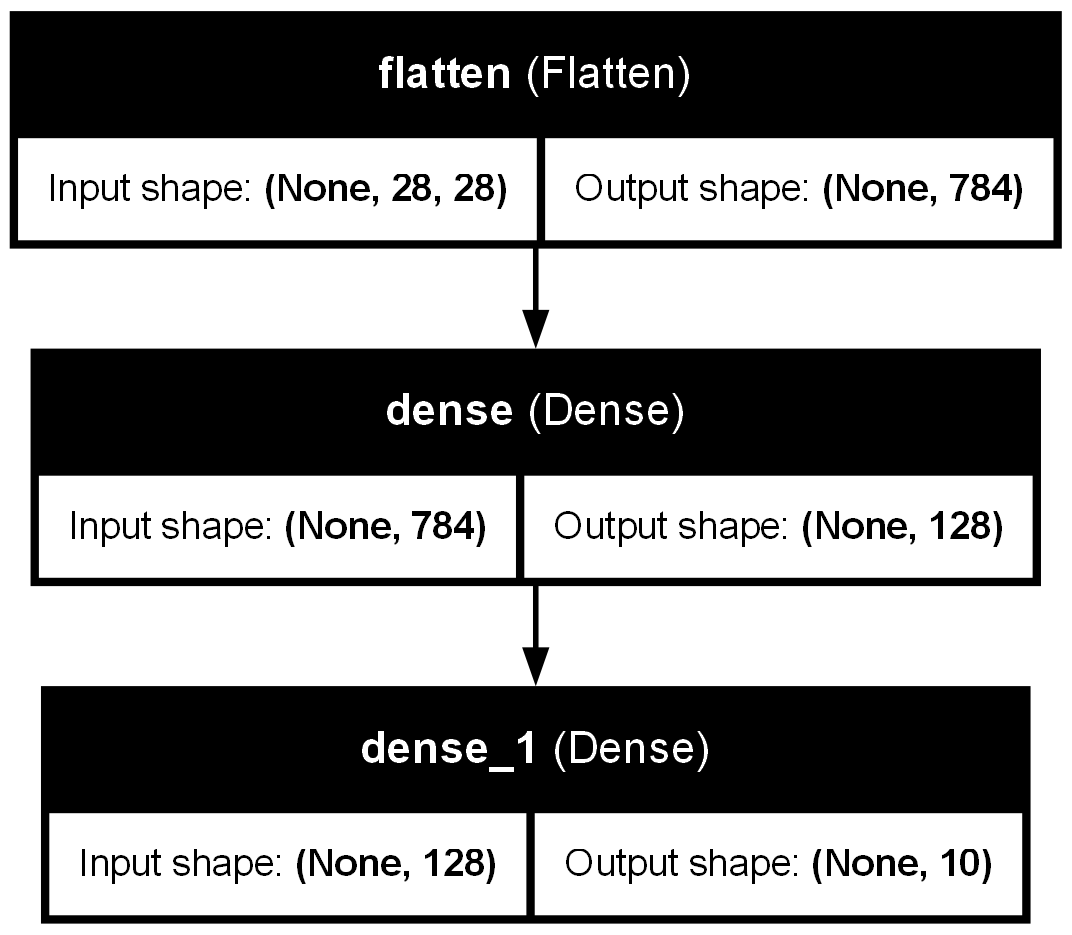

In [22]:
# mit plot_model aus Keras
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='Fashion_MNIST_model_diagram.png', show_shapes=True, show_layer_names=True)


6.2 Daten Visualisierung

Confusion Matrix

In [23]:
#import
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt

In [24]:
print(f"Original:  {test_labels[10:20]}")
print(f"Vorgesagt: {pred_labels[10:20]}")
print(f"len = {len(test_labels)} values")

Original:  [4 5 7 3 4 1 2 4 8 0]
Vorgesagt: [4 5 7 3 4 1 2 2 8 0]
len = 10000 values


In [25]:
cm = confusion_matrix(y_true=test_labels,y_pred=pred_labels)
print(cm,"\n")
print(list(enumerate(class_names)))

[[843   1  25  33   4   0  85   0   9   0]
 [  3 969   0  22   2   0   4   0   0   0]
 [ 13   0 800  18  87   0  80   0   2   0]
 [ 21   1  14 918  24   0  18   0   4   0]
 [  0   1  85  44 754   0 112   0   4   0]
 [  0   0   0   0   0 973   0  16   2   9]
 [132   0  85  42  47   0 681   0  13   0]
 [  0   0   0   0   0  30   0 903   0  67]
 [  5   0   5   4   3   2   2   2 977   0]
 [  0   0   0   0   0  13   1  14   0 972]] 

[(0, 'T-shirt/top'), (1, 'Trouser'), (2, 'Pullover'), (3, 'Dress'), (4, 'Coat'), (5, 'Sandal'), (6, 'Shirt'), (7, 'Sneaker'), (8, 'Bag'), (9, 'Ankle boot')]


Matrix Visualisierung

In [26]:
# selber Funktion
def plot_confusion_matrix(cm, classes, normalize=False,
                          title="Confusion matrix",
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting 'normalize=True'.
    """

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks,classes,rotation=45)
    plt.yticks(tick_marks,classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix ohne normalization")
    
    print(cm)

    thresh = cm.max()/2   # Schwellenwert
    for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j,i,cm[i,j],
                 horizontalalignment='center',
                 color = 'white' if cm[i,j] > thresh else 'black')
    
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')  



Confusion matrix ohne normalization
[[843   1  25  33   4   0  85   0   9   0]
 [  3 969   0  22   2   0   4   0   0   0]
 [ 13   0 800  18  87   0  80   0   2   0]
 [ 21   1  14 918  24   0  18   0   4   0]
 [  0   1  85  44 754   0 112   0   4   0]
 [  0   0   0   0   0 973   0  16   2   9]
 [132   0  85  42  47   0 681   0  13   0]
 [  0   0   0   0   0  30   0 903   0  67]
 [  5   0   5   4   3   2   2   2 977   0]
 [  0   0   0   0   0  13   1  14   0 972]]


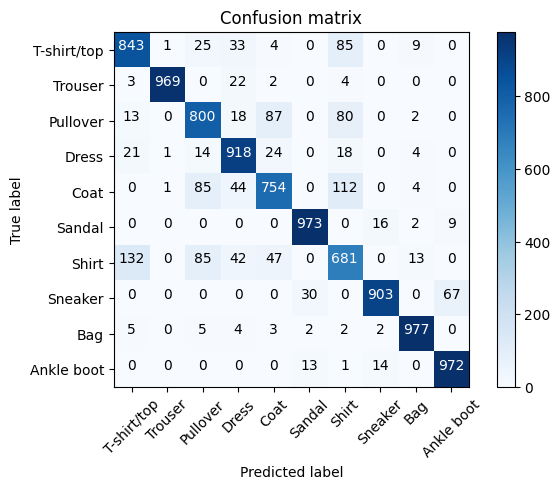

In [27]:
#Visualisierung
plot_confusion_matrix(cm=cm, classes=class_names)
# plot_confusion_matrix(cm=cm, classes=class_names, normalize=True)

7. Modell speichern

In [28]:
import os.path

In [32]:
PROJEKT_PATH = r"\Users\MariaSizintseva\Desktop\MariaDocs\marrfusProgBackup\python\ML\tensor_scikit\Fasion_MNIST_MS"
MODEL_PATH = os.path.join(PROJEKT_PATH,'Fasion_MNIST_model.keras')

if os.path.isfile(MODEL_PATH) is False:
    model.save(MODEL_PATH)
    print('successfully saved')
else:
    print('Already exist')



Already exist
